In [1]:
%%writefile ngram_lm.py
from __future__ import annotations
import math
import re
from collections import Counter
from typing import Dict, Iterable, List, Sequence, Tuple
BOS, EOS, UNK = "<s>", "</s>", "<unk>"
_TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")
def tokenize(text: str) -> List[str]:
    return _TOKEN_RE.findall(text.lower())

def build_vocabulary(corpus: Iterable[Sequence[str]], min_count: int = 1) -> Tuple[set, Counter]:
    word_counts: Counter = Counter()
    for sent in corpus:
        word_counts.update(sent)
    vocab = {w for w, c in word_counts.items() if c >= min_count}
    vocab.update({BOS, EOS, UNK})
    return vocab, word_counts

def pad_sentence(sent: Sequence[str], n: int) -> List[str]:
    return [BOS] * (n - 1) + list(sent) + [EOS]

def count_ngrams(corpus: Iterable[Sequence[str]], n: int) -> Counter:
    counts: Counter = Counter()
    for sent in corpus:
        padded = pad_sentence(sent, n)
        for i in range(len(padded) - n + 1):
            counts[tuple(padded[i:i + n])] += 1
    return counts

class NGramLanguageModel:
    def __init__(self, n: int, smoothing: str = "mle", k: float = 1.0, min_count: int = 1):
        self.n = n
        self.smoothing = smoothing
        self.k = k
        self.min_count = min_count
        self.vocab: set = set()
        self.ngram_counts: Counter = Counter()
        self.context_counts: Counter = Counter()
        self._succ: Dict[Tuple[str, ...], Counter] = {}
        self._canon: Dict[str, str] = {}
        self.total_tokens = 0
        self.V = 0

    def fit(self, corpus: Iterable[Sequence[str]]) -> "NGramLanguageModel":
        corpus = corpus if isinstance(corpus, list) else list(corpus)
        self.vocab, _ = build_vocabulary(corpus, self.min_count)
        self._canon = {w: w for w in self.vocab}
        self.ngram_counts = count_ngrams((self._map_oov(s) for s in corpus), self.n)
        self.context_counts = Counter()
        for gram, c in self.ngram_counts.items():
            self.context_counts[gram[:-1]] += c
        self._succ = {}
        self.total_tokens = sum(self.ngram_counts.values())
        self.V = len(self.vocab) - 1
        return self

    def set_smoothing(self, smoothing: str, k: float = 1.0) -> "NGramLanguageModel":
        if smoothing not in ("mle", "laplace"):
            raise ValueError("smoothing phải là 'mle' hoặc 'laplace'")
        if k <= 0:
            raise ValueError("k phải > 0")
        self.smoothing, self.k = smoothing, k
        return self

    def _map_oov(self, sent: Sequence[str]) -> List[str]:
        get = self._canon.get
        return [get(w, UNK) for w in sent]

    def _norm_context(self, context: Sequence[str]) -> Tuple[str, ...]:
        m = self.n - 1
        if m == 0:
            return ()
        ctx = self._map_oov(context)[-m:]
        return tuple([BOS] * (m - len(ctx)) + ctx)

    def probability(self, context: Sequence[str], word: str) -> float:
        ctx = self._norm_context(context)
        w = word if word in self.vocab else UNK
        c_hw = self.ngram_counts.get(ctx + (w,), 0)
        c_h = self.total_tokens if self.n == 1 else self.context_counts.get(ctx, 0)
        if self.smoothing == "mle":
            return c_hw / c_h if c_h > 0 else 0.0
        return (c_hw + self.k) / (c_h + self.k * self.V)

    def prepare_contexts(self, contexts: Iterable[Sequence[str]]) -> None:
        wanted = {self._norm_context(c) for c in contexts} - set(self._succ)
        if not wanted:
            return
        found = {c: Counter() for c in wanted}
        for gram, cnt in self.ngram_counts.items():
            ctx = gram[:-1]
            if ctx in found:
                found[ctx][gram[-1]] += cnt
        self._succ.update(found)

    def next_word_distribution(self, context: Sequence[str], top_k: int | None = None) -> List[Tuple[str, float]]:
        ctx = self._norm_context(context)
        if self.smoothing == "mle":
            if ctx not in self._succ:
                self.prepare_contexts([context])
            succ = self._succ[ctx]
            c_h = self.total_tokens if self.n == 1 else self.context_counts.get(ctx, 0)
            dist = [(w, c / c_h) for w, c in succ.items()] if c_h else []
        else:
            dist = [(w, self.probability(context, w)) for w in self.vocab if w != BOS]
        dist.sort(key=lambda x: (-x[1], x[0]))
        return dist[:top_k] if top_k else dist

    def top1_evaluate(self, corpus: Sequence[Sequence[str]]):
        m = self.n - 1
        positions = []
        for s in corpus:
            padded = [BOS] * m + self._map_oov(s) + [EOS]
            for i in range(m, len(padded)):
                positions.append((tuple(padded[i - m:i]), padded[i]))
        self.prepare_contexts({c for c, _ in positions})
        best = {}
        right, wrong, unseen = [], [], 0
        for ctx, true in positions:
            succ = self._succ[ctx]
            if not succ:
                unseen += 1
                continue
            if ctx not in best:
                best[ctx] = min(succ.items(), key=lambda kv: (-kv[1], kv[0]))[0]
            pred = best[ctx]
            c_h = self.total_tokens if self.n == 1 else self.context_counts[ctx]
            item = (ctx, pred, succ[pred] / c_h, true, succ.get(true, 0) / c_h)
            (right if pred == true else wrong).append(item)
        tot = len(right) + len(wrong)
        return (len(right) / tot if tot else float("nan")), tot, unseen, right, wrong

    def sentence_log_probability(self, sentence: Sequence[str]) -> float:
        padded = pad_sentence(self._map_oov(sentence), self.n)
        total = 0.0
        for i in range(self.n - 1, len(padded)):
            p = self.probability(padded[max(0, i - self.n + 1):i], padded[i])
            if p <= 0.0:
                return float("-inf")
            total += math.log(p)
        return total

    def sentence_probability(self, sentence: Sequence[str]) -> float:
        lp = self.sentence_log_probability(sentence)
        return 0.0 if lp == float("-inf") else math.exp(lp)

    def perplexity(self, corpus: Iterable[Sequence[str]]) -> float:
        total_lp, n_tokens = 0.0, 0
        for sent in corpus:
            lp = self.sentence_log_probability(sent)
            if lp == float("-inf"):
                return float("inf")
            total_lp += lp
            n_tokens += len(sent) + 1
        return math.exp(-total_lp / n_tokens) if n_tokens else float("nan")

    def unseen_ngram_rate(self, corpus: Iterable[Sequence[str]]) -> float:
        unseen = total = 0
        for sent in corpus:
            padded = pad_sentence(self._map_oov(sent), self.n)
            for i in range(len(padded) - self.n + 1):
                total += 1
                unseen += self.ngram_counts.get(tuple(padded[i:i + self.n]), 0) == 0
        return unseen / total if total else float("nan")

    def rank_candidates(self, context: Sequence[str], candidates: Dict[str, Sequence[str]],
                        length_normalize: bool = False):
        results = []
        for name, cand in candidates.items():
            ctx = list(context)
            lp = 0.0
            for w in cand:
                p = self.probability(ctx, w)
                if p <= 0:
                    lp = float("-inf")
                    break
                lp += math.log(p)
                ctx.append(w)
            if length_normalize and lp != float("-inf"):
                lp /= len(cand)
            results.append((name, lp))
        return sorted(results, key=lambda x: -x[1])

if __name__ == "__main__":
    toy = [s.split() for s in ["the cat eats fish", "the cat likes fish", "the dog eats meat"]]
    lm = NGramLanguageModel(2).fit(toy)
    print("P(cat|the) =", lm.probability(["the"], "cat"))
    print("P(S) =", lm.sentence_probability(toy[0]))

Writing ngram_lm.py


In [2]:
import os, sys, gzip, json, re, math, random, time, importlib
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import ngram_lm
importlib.reload(ngram_lm)
from ngram_lm import NGramLanguageModel, tokenize, BOS, EOS, UNK
SEED = 42
MAX_DOCS = 30000
MIN_COUNT = 3
EVAL_MAX_SENT = 20000
TOP1_MAX_SENT = 3000
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Nạp C4 và chia train / validation / test (80/10/10 **theo document**)

In [3]:
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = [n for n in uploaded if n.endswith('.json.gz')][0]
except ImportError:
    DATA_PATH = "c4_sample.json.gz"
def load_c4(path, max_docs=None):
    docs, urls = [], []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            text = str(rec.get('text', '') or '').strip()
            if not text:
                continue
            sents = []
            for para in text.split('\n'):
                for s in re.split(r'(?<=[.!?])\s+', para):
                    toks = [sys.intern(t) for t in tokenize(s)]
                    if toks:
                        sents.append(toks)
            if sents:
                docs.append(sents); urls.append(str(rec.get('url', '') or ''))
            if max_docs and len(docs) >= max_docs:
                break
    return docs, urls

docs, urls = load_c4(DATA_PATH, MAX_DOCS)
order = list(range(len(docs))); random.Random(SEED).shuffle(order)
a, b = int(0.8 * len(order)), int(0.9 * len(order))
train_docs = [docs[i] for i in order[:a]]
valid_docs = [docs[i] for i in order[a:b]]
test_docs  = [docs[i] for i in order[b:]]
train = [s for d in train_docs for s in d]
valid = [s for d in valid_docs for s in d]
test  = [s for d in test_docs  for s in d]
rs = random.Random(SEED)
def sample(x, n): return x if len(x) <= n else rs.sample(x, n)
train_eval, valid_eval, test_eval = sample(train, EVAL_MAX_SENT), sample(valid, EVAL_MAX_SENT), sample(test, EVAL_MAX_SENT)

Saving c4-train.00000-of-01024-30K.json.gz to c4-train.00000-of-01024-30K.json.gz


## Statistics

In [4]:
models = {n: NGramLanguageModel(n, "mle", min_count=MIN_COUNT).fit(train) for n in (1, 2, 3)}
tr_words = Counter(w for s in train for w in s)
rows = []
for n, name in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram")):
    c = models[n].ngram_counts
    singles = sum(1 for v in c.values() if v == 1)
    rows.append({"Model": name, "# unique n-grams": len(c), "# n-gram tokens": sum(c.values()),
                 "# n-grams count=1": singles, "% count=1": 100 * singles / len(c)})
exp1 = pd.DataFrame(rows); exp1

,Model,# unique n-grams,# n-gram tokens,# n-grams count=1,% count=1
0,Unigram,65807,9425640,0,0.0000
1,Bigram,2250818,9425640,1539034,68.3767
2,Trigram,5748564,9425640,4899188,85.2246


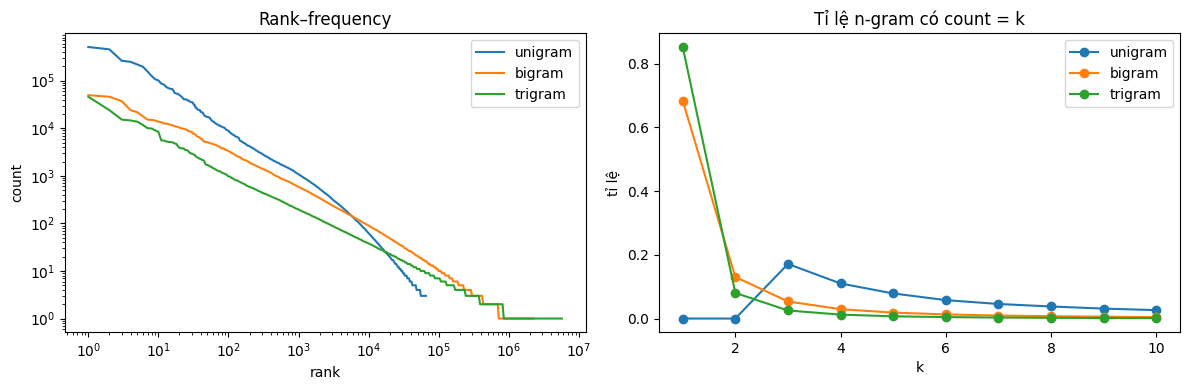

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n, name in ((1, "unigram"), (2, "bigram"), (3, "trigram")):
    freqs = np.sort(np.fromiter(models[n].ngram_counts.values(), dtype=np.int64))[::-1]
    pos = np.unique(np.logspace(0, math.log10(len(freqs)), 400).astype(int)) - 1
    ax[0].loglog(pos + 1, freqs[pos], label=name)
ax[0].set(title="Rank–frequency", xlabel="rank", ylabel="count"); ax[0].legend()
for n, name in ((1, "unigram"), (2, "bigram"), (3, "trigram")):
    cnt = Counter(models[n].ngram_counts.values()); total = len(models[n].ngram_counts)
    ax[1].plot(range(1, 11), [cnt[k] / total for k in range(1, 11)], marker="o", label=name)
ax[1].set(title="Tỉ lệ n-gram có count = k", xlabel="k", ylabel="tỉ lệ"); ax[1].legend()
plt.tight_layout(); plt.savefig("fig_frequency.png", dpi=120); plt.show()

## MLE vs Smoothing and Uni/Bi/Tri

In [6]:
def evaluate(lm):
    return {"Train PPL": lm.perplexity(train_eval), "Valid PPL": lm.perplexity(valid_eval), "Test PPL": lm.perplexity(test_eval),
            "Unseen n-gram % (valid)": 100 * lm.unseen_ngram_rate(valid_eval)}
names = {1: "Unigram", 2: "Bigram", 3: "Trigram"}
rows = []
for n in (1, 2, 3):
    for sm in ("mle", "laplace"):
        models[n].set_smoothing(sm, 1.0)
        rows.append({"n": n, "Model": names[n], "Smoothing": sm, **evaluate(models[n])})
        print(names[n], sm)
ppl = pd.DataFrame(rows)
print("\nExperiment 2 (bigram/trigram, MLE vs Laplace):")
display(ppl[ppl.n >= 2].drop(columns="n"))
print("Experiment 3 (unigram/bigram/trigram):")
display(ppl.drop(columns="n"))

Unigram mle
Unigram laplace
Bigram mle
Bigram laplace
Trigram mle
Trigram laplace

Experiment 2 (bigram/trigram, MLE vs Laplace):


,Model,Smoothing,Train PPL,Valid PPL,Test PPL,Unseen n-gram % (valid)
2,Bigram,mle,168.3960,inf,inf,17.8795
3,Bigram,laplace,"2,431.3540","2,815.6904","2,781.5721",17.8795
4,Trigram,mle,15.1006,inf,inf,55.5828
5,Trigram,laplace,"12,085.9877","19,073.9445","18,847.1527",55.5828


Experiment 3 (unigram/bigram/trigram):


,Model,Smoothing,Train PPL,Valid PPL,Test PPL,Unseen n-gram % (valid)
0,Unigram,mle,"1,458.1938","1,316.8355","1,306.2826",0.0000
1,Unigram,laplace,"1,458.8468","1,318.7212","1,308.1322",0.0000
2,Bigram,mle,168.3960,inf,inf,17.8795
3,Bigram,laplace,"2,431.3540","2,815.6904","2,781.5721",17.8795
4,Trigram,mle,15.1006,inf,inf,55.5828
5,Trigram,laplace,"12,085.9877","19,073.9445","18,847.1527",55.5828


### MLE vs Laplace
MLE:
Khi một n-gram chưa xuất hiện trong train, `C(h,w)=0`, nên xác suất bằng 0. Chỉ cần một token trong tập đánh giá có xác suất 0 thì log probability của câu chứa token đó là `-inf`, và perplexity của tập có thể trở thành `inf`.

Laplace:
n-gram chưa thấy vẫn nhận xác suất dương. Đổi lại, xác suất được phân bổ lại cho toàn vocabulary;

### Unigram / Bigram / Trigram

Khi tăng `n`, context dài hơn nên model có thể biểu diễn phụ thuộc cục bộ chi tiết hơn. Vì vậy training perplexity có thể giảm. Tuy nhiên, số tổ hợp context–word cũng tăng, làm dữ liệu thưa hơn.

Do đó validation/test không nhất thiết cải thiện theo training. Nếu training PPL tiếp tục giảm nhưng validation/test PPL không giảm hoặc tăng, đồng thời unseen n-gram tăng, đó là dấu hiệu phù hợp với sparsity và có thể đi kèm overfitting.

Corpus lớn hơn cung cấp thêm count cho các combination hiếm, nên thường làm giảm sparsity và giúp context dài hữu ích hơn.

In [7]:
K_GRID = [
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
]
best_k = {}
tuning_rows = []
for n in (2, 3):
    lm = models[n]
    best_ppl = float("inf")
    best_value = None
    for k in K_GRID:
        t0 = time.time()
        lm.set_smoothing("laplace", k)
        valid_ppl = lm.perplexity(valid_eval)
        tuning_rows.append({
            "n": n,
            "Model": names[n],
            "k": k,
            "Valid PPL": valid_ppl,
            "time (s)": time.time() - t0,
        })
        print(
            f"  k={k:<7g} | "
            f"Valid PPL={valid_ppl:,.4f} | "
            f"{time.time() - t0:.1f}s"
        )
        if valid_ppl < best_ppl:
            best_ppl = valid_ppl
            best_value = k
    best_k[n] = best_value
    print(
        f"=> {names[n]}: best_k={best_value} "
        f"(Valid PPL={best_ppl:,.4f})"
    )
tuning = pd.DataFrame(tuning_rows)
display(tuning)
print("\nbest_k =", best_k)

  k=0.0001  | Valid PPL=1,033.5351 | 1.2s
  k=0.0003  | Valid PPL=883.0314 | 0.7s
  k=0.001   | Valid PPL=775.3530 | 0.7s
  k=0.003   | Valid PPL=732.2572 | 0.7s
  k=0.01    | Valid PPL=758.0913 | 0.7s
  k=0.03    | Valid PPL=874.4230 | 0.7s
  k=0.1     | Valid PPL=1,165.2414 | 0.7s
  k=0.3     | Valid PPL=1,691.9549 | 0.7s
  k=1       | Valid PPL=2,815.6904 | 0.7s
  k=3       | Valid PPL=4,783.1678 | 0.7s
=> Bigram: best_k=0.003 (Valid PPL=732.2572)
  k=0.0001  | Valid PPL=5,180.8459 | 0.8s
  k=0.0003  | Valid PPL=4,391.8628 | 0.9s
  k=0.001   | Valid PPL=4,131.4479 | 0.8s
  k=0.003   | Valid PPL=4,366.3932 | 0.8s
  k=0.01    | Valid PPL=5,188.4499 | 1.3s
  k=0.03    | Valid PPL=6,617.4271 | 1.3s
  k=0.1     | Valid PPL=9,265.6357 | 0.8s
  k=0.3     | Valid PPL=13,069.8112 | 0.8s
  k=1       | Valid PPL=19,073.9445 | 0.8s
  k=3       | Valid PPL=26,026.3784 | 0.8s
=> Trigram: best_k=0.001 (Valid PPL=4,131.4479)


,n,Model,k,Valid PPL,time (s)
0,2,Bigram,0.0001,"1,033.5351",1.2226
1,2,Bigram,0.0003,883.0314,0.7360
2,2,Bigram,0.0010,775.3530,0.7209
3,2,Bigram,0.0030,732.2572,0.7372
4,2,Bigram,0.0100,758.0913,0.7136
5,2,Bigram,0.0300,874.4230,0.7119
6,2,Bigram,0.1000,"1,165.2414",0.7098
7,2,Bigram,0.3000,"1,691.9549",0.7189
8,2,Bigram,1.0000,"2,815.6904",0.7290
9,2,Bigram,3.0000,"4,783.1678",0.7194



best_k = {2: 0.003, 3: 0.001}


n                           2                         3            
smoothing       add-k k=0.003 laplace k=1 add-k k=0.001 laplace k=1
train sentences                                                    
47628                796.9570  2,284.8583    4,127.7930  9,005.6504
124578               805.6669  2,679.0007    4,494.8168 12,978.3051
253348               774.3955  2,807.6885    4,436.8357 16,086.9106
510705               732.2572  2,815.6904    4,131.4479 19,073.9445

n,2,3
train sentences,,
47628,28.6205,69.3946
124578,24.2794,64.6464
253348,20.9575,60.3436
510705,17.8795,55.5828


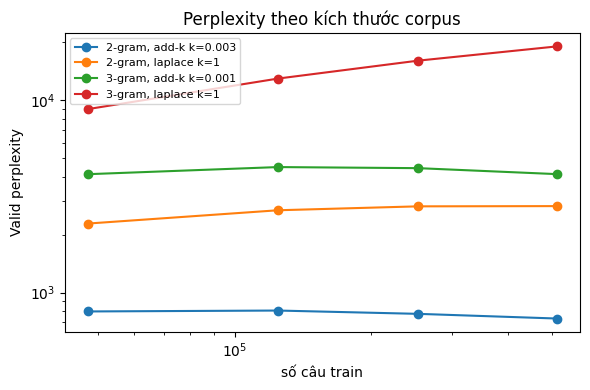

In [8]:
fracs = [0.1, 0.25, 0.5, 1.0]
size_rows = []
for f in fracs:
    sub = [s for d in train_docs[: int(len(train_docs) * f)] for s in d]
    for n in (2, 3):
        lm = models[n] if f == 1.0 else NGramLanguageModel(n, "laplace", min_count=MIN_COUNT).fit(sub)
        for label, kk in (("laplace k=1", 1.0), (f"add-k k={best_k[n]}", best_k[n])):
            lm.set_smoothing("laplace", kk)
            size_rows.append({"train sentences": len(sub), "n": n, "smoothing": label,
                              "Valid PPL": lm.perplexity(valid_eval), "unseen % (valid)": 100 * lm.unseen_ngram_rate(valid_eval)})
        if f != 1.0: del lm
size_df = pd.DataFrame(size_rows)
display(size_df.pivot_table(index="train sentences", columns=["n", "smoothing"], values="Valid PPL"))
display(size_df.pivot_table(index="train sentences", columns="n", values="unseen % (valid)"))
fig, ax = plt.subplots(figsize=(6, 4))
for (n, sm), g in size_df.groupby(["n", "smoothing"]):
    ax.plot(g["train sentences"], g["Valid PPL"], marker="o", label=f"{n}-gram, {sm}")
ax.set(xscale="log", yscale="log", xlabel="số câu train", ylabel="Valid perplexity", title="Perplexity theo kích thước corpus"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("fig_corpus_size.png", dpi=120); plt.show()

## Next-word prediction

In [9]:
def next_after(sentences, context):
    m = len(context)
    for s in sentences:
        for i in range(len(s) - m):
            if s[i:i + m] == list(context):
                return s[i + m]
    return None

contexts = [("the", "cat"), ("natural", "language"), ("machine", "learning"), ("thank", "you"),
            ("click", "here"), ("terms", "of"), ("for", "more"), ("one", "of")]
models[2].set_smoothing("mle"); models[3].set_smoothing("mle")
pred_rows, table = [], []
for ctx in contexts:
    actual = next_after(test, ctx) or next_after(valid, ctx) or "(không có trong valid/test)"
    d_tri = models[3].next_word_distribution(list(ctx), top_k=3)
    d_bi = models[2].next_word_distribution(list(ctx[-1:]), top_k=3)
    print(f"Context: {' '.join(ctx)!r}   actual next (lần đầu trong test): {actual}")
    print("   trigram:", [(w, round(p, 3)) for w, p in d_tri] or "context chưa thấy trong train")
    print("   bigram :", [(w, round(p, 3)) for w, p in d_bi])
    table.append({"Context": " ".join(ctx), "Prediction (trigram)": d_tri[0][0] if d_tri else "-", "Actual next word": actual})
    for name, d in (("trigram_mle", d_tri), ("bigram_mle", d_bi)):
        pred_rows.append({"type": "next_word", "model": name, "context": " ".join(ctx),
                          "prediction": d[0][0] if d else "", "prob": d[0][1] if d else 0.0, "actual": actual})
pd.DataFrame(table)

Context: 'the cat'   actual next (lần đầu trong test): family
   trigram: [('</s>', 0.065), ('box', 0.052), ('and', 0.039)]
   bigram : [('</s>', 0.104), ('and', 0.046), ('house', 0.035)]
Context: 'natural language'   actual next (lần đầu trong test): analysis
   trigram: [('processing', 0.357), ('laboratory', 0.214), ('</s>', 0.143)]
   bigram : [('</s>', 0.124), ('and', 0.104), ('of', 0.05)]
Context: 'machine learning'   actual next (lần đầu trong test): portfolio
   trigram: [('and', 0.125), ('</s>', 0.062), ('algorithms', 0.062)]
   bigram : [('</s>', 0.087), ('and', 0.079), ('to', 0.058)]
Context: 'thank you'   actual next (lần đầu trong test): for
   trigram: [('for', 0.368), ('</s>', 0.19), ('so', 0.085)]
   bigram : [('can', 0.112), ('are', 0.068), ('have', 0.054)]
Context: 'click here'   actual next (lần đầu trong test): to
   trigram: [('to', 0.452), ('</s>', 0.303), ('for', 0.152)]
   bigram : [('</s>', 0.248), ('to', 0.086), ('is', 0.074)]
Context: 'terms of'   actual next 

,Context,Prediction (trigram),Actual next word
0,the cat,</s>,family
1,natural language,processing,analysis
2,machine learning,and,portfolio
3,thank you,for,for
4,click here,to,to
5,terms of,the,the
6,for more,information,than
7,one of,the,the


In [10]:
res = {}
for name, n in (("bigram_mle", 2), ("trigram_mle", 3)):
    models[n].set_smoothing("mle")
    acc, tot, unseen, right, wrong = models[n].top1_evaluate(test[:TOP1_MAX_SENT])
    res[name] = (right, wrong)
    print(f"{name}: top-1 acc = {acc:.3f} trên {tot:,} vị trí có context đã thấy; {unseen:,} vị trí có context chưa thấy")
    pred_rows.append({"type": "top1_accuracy", "model": name, "context": f"test[:{TOP1_MAX_SENT}]", "prediction": "", "prob": acc, "actual": tot})

bigram_mle: top-1 acc = 0.139 trên 54,713 vị trí có context đã thấy; 0 vị trí có context chưa thấy
trigram_mle: top-1 acc = 0.162 trên 45,340 vị trí có context đã thấy; 9,373 vị trí có context chưa thấy


## Sentence ranking

In [11]:
ctx = ["machine", "learning"]
cands = {"A: is useful for nlp": ["is", "useful", "for", "nlp"],
         "B: banana computer quickly": ["banana", "computer", "quickly"],
         "C: studies language models": ["studies", "language", "models"]}
configs = [("bigram_mle", 2, "mle", 1.0), ("bigram_laplace", 2, "laplace", 1.0),
           (f"bigram_addk", 2, "laplace", best_k[2]), (f"trigram_addk", 3, "laplace", best_k[3])]
rank_rows = []
for name, n, sm, k in configs:
    models[n].set_smoothing(sm, k)
    for norm in (False, True):
        r = models[n].rank_candidates(ctx, cands, length_normalize=norm)
        print(f"{name:15} norm={norm!s:5} ->", [(c.split(':')[0], round(s, 2)) for c, s in r])
        rank_rows += [{"type": "ranking", "model": name + ("_norm" if norm else ""), "context": " ".join(ctx),
                       "prediction": c, "prob": s, "actual": ""} for c, s in r]

lm = models[2].set_smoothing("laplace", best_k[2]); rng = random.Random(SEED); wins = tot = 0
for s in valid_eval[:2000]:
    if len(s) < 4: continue
    sh = s[:]; rng.shuffle(sh)
    if sh == s: continue
    tot += 1; wins += lm.sentence_log_probability(s) > lm.sentence_log_probability(sh)
print(f"Câu gốc có log-prob cao hơn câu xáo trộn: {wins}/{tot} = {wins/tot:.3f}")
rank_rows.append({"type": "shuffle_test", "model": "bigram_addk", "context": "valid sentences", "prediction": "", "prob": wins / tot, "actual": tot})

bigram_mle      norm=False -> [('A', -25.64), ('B', -inf), ('C', -inf)]
bigram_mle      norm=True  -> [('A', -6.41), ('B', -inf), ('C', -inf)]
bigram_laplace  norm=False -> [('C', -32.65), ('B', -33.33), ('A', -33.82)]
bigram_laplace  norm=True  -> [('A', -8.45), ('C', -10.88), ('B', -11.11)]
bigram_addk     norm=False -> [('A', -25.95), ('C', -33.64), ('B', -38.08)]
bigram_addk     norm=True  -> [('A', -6.49), ('C', -11.21), ('B', -12.69)]
trigram_addk    norm=False -> [('B', -34.08), ('C', -34.09), ('A', -37.2)]
trigram_addk    norm=True  -> [('A', -9.3), ('B', -11.36), ('C', -11.36)]
Câu gốc có log-prob cao hơn câu xáo trộn: 1856/1889 = 0.983


In [12]:
def choose_error_examples(right, wrong, n_each=2):
    correct = sorted(right, key=lambda x: -x[2])[:n_each]
    zero_expected = [x for x in wrong if x[4] == 0]
    selected = list(zero_expected[:1])
    remaining = [x for x in wrong if x not in selected]
    selected.extend(sorted(remaining, key=lambda x: -x[2])[: max(0, n_each-len(selected))])
    return correct, selected[:n_each]

def infer_error_cause(model_name, record):
    context, pred, p_pred, true, p_true = record
    if true == UNK:
        return "vocabulary limitation"
    if p_true == 0:
        return "unseen n-gram / sparsity"
    if model_name.startswith("bigram"):
        return "context quá ngắn"
    if p_pred > 0.5 and p_pred > p_true:
        return "training frequency / sparsity"
    return "insufficient training data / possible domain mismatch"
error_rows = []
for name in ("bigram_mle", "trigram_mle"):
    right, wrong = res[name]
    correct_examples, wrong_examples = choose_error_examples(right, wrong, 2)
    print(f"\n=== {name}: 2 prediction đúng ===")
    for record in correct_examples:
        ctx_, pred, pp, true, ptrue = record
        print(
            f"Context: {' '.join(ctx_)} | prediction={pred} | "
            f"P(pred)={pp:.4f} | expected={true} | P(expected)={ptrue:.4f}"
        )
        error_rows.append({
            "Model": name,
            "Case": "Correct",
            "Context": " ".join(ctx_),
            "Prediction": pred,
            "P(prediction)": pp,
            "Expected": true,
            "P(expected)": ptrue,
            "Likely cause / note": "prediction đúng",
        })
    print(f"=== {name}: 2 prediction sai ===")
    for record in wrong_examples:
        ctx_, pred, pp, true, ptrue = record
        cause = infer_error_cause(name, record)
        print(
            f"Context: {' '.join(ctx_)} | prediction={pred} | "
            f"P(pred)={pp:.4f} | expected={true} | "
            f"P(expected)={ptrue:.4f} | cause={cause}"
        )
        error_rows.append({
            "Model": name,
            "Case": "Wrong",
            "Context": " ".join(ctx_),
            "Prediction": pred,
            "P(prediction)": pp,
            "Expected": true,
            "P(expected)": ptrue,
            "Likely cause / note": cause,
        })
error_df = pd.DataFrame(error_rows)
display(error_df)

print("\nLưu ý: cause là giải thích dựa trên dấu hiệu quan sát được, không phải causal proof tuyệt đối cho từng case.")


=== bigram_mle: 2 prediction đúng ===
Context: couldn | prediction=t | P(pred)=1.0000 | expected=t | P(expected)=1.0000
Context: burkina | prediction=faso | P(pred)=1.0000 | expected=faso | P(expected)=1.0000
=== bigram_mle: 2 prediction sai ===
Context: <s> | prediction=the | P(pred)=0.0899 | expected=dehydrate | P(expected)=0.0000 | cause=unseen n-gram / sparsity
Context: rosebery | prediction=kids | P(pred)=1.0000 | expected=mascot | P(expected)=0.0000 | cause=unseen n-gram / sparsity

=== trigram_mle: 2 prediction đúng ===
Context: or equivalents | prediction=</s> | P(pred)=1.0000 | expected=</s> | P(expected)=1.0000
Context: <s> mcgraw | prediction=hill | P(pred)=1.0000 | expected=hill | P(expected)=1.0000
=== trigram_mle: 2 prediction sai ===
Context: <unk> working | prediction=for | P(pred)=0.1333 | expected=<unk> | P(expected)=0.0000 | cause=vocabulary limitation
Context: dehydrate in | prediction=the | P(pred)=1.0000 | expected=95 | P(expected)=0.0000 | cause=unseen n-gram / 

,Model,Case,Context,Prediction,P(prediction),Expected,P(expected),Likely cause / note
0,bigram_mle,Correct,couldn,t,1.0000,t,1.0000,prediction đúng
1,bigram_mle,Correct,burkina,faso,1.0000,faso,1.0000,prediction đúng
2,bigram_mle,Wrong,<s>,the,0.0899,dehydrate,0.0000,unseen n-gram / sparsity
3,bigram_mle,Wrong,rosebery,kids,1.0000,mascot,0.0000,unseen n-gram / sparsity
4,trigram_mle,Correct,or equivalents,</s>,1.0000,</s>,1.0000,prediction đúng
5,trigram_mle,Correct,<s> mcgraw,hill,1.0000,hill,1.0000,prediction đúng
6,trigram_mle,Wrong,<unk> working,for,0.1333,<unk>,0.0000,vocabulary limitation
7,trigram_mle,Wrong,dehydrate in,the,1.0000,95,0.0000,unseen n-gram / sparsity



Lưu ý: cause là giải thích dựa trên dấu hiệu quan sát được, không phải causal proof tuyệt đối cho từng case.


## Context length

,Model,Context length,# unique n-grams,# n-grams count=1,Train PPL (Laplace k=1),Validation PPL (Laplace k=1),Test PPL (Laplace k=1),Unseen valid % (MLE),Unseen test % (MLE)
0,Unigram,0,65807,0,"1,458.8468","1,318.7212","1,308.1322",0.0000,0.0000
1,Bigram,1,2250818,1539034,"2,431.3540","2,815.6904","2,781.5721",17.8795,17.9748
2,Trigram,2,5748564,4899188,"12,085.9877","19,073.9445","18,847.1527",55.5828,55.2308



Interpretation:
Unigram: context=0, unique=65,807, singleton=0, train=1458.8468, valid=1318.7212, test=1308.1322, unseen-valid=0.00%
Bigram: context=1, unique=2,250,818, singleton=1,539,034, train=2431.3540, valid=2815.6904, test=2781.5721, unseen-valid=17.88%
Trigram: context=2, unique=5,748,564, singleton=4,899,188, train=12085.9877, valid=19073.9445, test=18847.1527, unseen-valid=55.58%


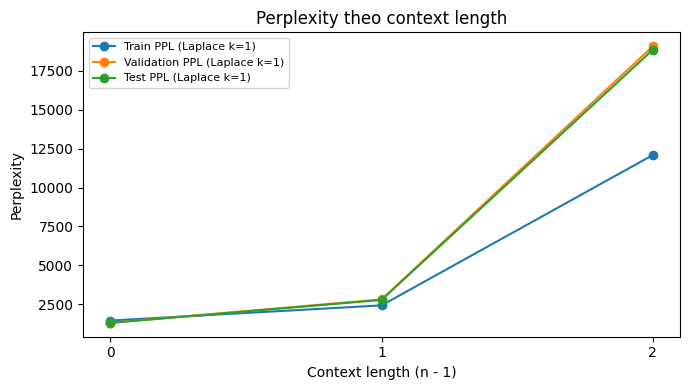

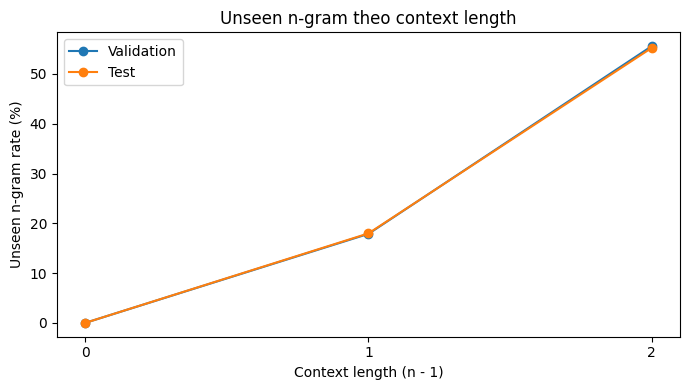

In [13]:
context_rows = []
for n in (1, 2, 3):
    lm = models[n]
    lm.set_smoothing("laplace", 1.0)
    train_ppl = lm.perplexity(train_eval)
    valid_ppl = lm.perplexity(valid_eval)
    test_ppl = lm.perplexity(test_eval)
    lm.set_smoothing("mle")
    unseen_valid = 100 * lm.unseen_ngram_rate(valid_eval)
    unseen_test = 100 * lm.unseen_ngram_rate(test_eval)
    context_rows.append({
        "Model": names[n],
        "Context length": n - 1,
        "# unique n-grams": len(lm.ngram_counts),
        "# n-grams count=1": sum(c == 1 for c in lm.ngram_counts.values()),
        "Train PPL (Laplace k=1)": train_ppl,
        "Validation PPL (Laplace k=1)": valid_ppl,
        "Test PPL (Laplace k=1)": test_ppl,
        "Unseen valid % (MLE)": unseen_valid,
        "Unseen test % (MLE)": unseen_test,
    })
    lm.set_smoothing("laplace", 1.0)
context_df = pd.DataFrame(context_rows)
display(context_df)
print("\nInterpretation:")
for _, row in context_df.iterrows():
    print(
        f"{row['Model']}: context={int(row['Context length'])}, "
        f"unique={int(row['# unique n-grams']):,}, "
        f"singleton={int(row['# n-grams count=1']):,}, "
        f"train={row['Train PPL (Laplace k=1)']:.4f}, "
        f"valid={row['Validation PPL (Laplace k=1)']:.4f}, "
        f"test={row['Test PPL (Laplace k=1)']:.4f}, "
        f"unseen-valid={row['Unseen valid % (MLE)']:.2f}%"
    )
plt.figure(figsize=(7, 4))
for col in (
    "Train PPL (Laplace k=1)",
    "Validation PPL (Laplace k=1)",
    "Test PPL (Laplace k=1)",
):
    plt.plot(
        context_df["Context length"],
        context_df[col],
        marker="o",
        label=col,
    )
plt.xlabel("Context length (n - 1)")
plt.ylabel("Perplexity")
plt.title("Perplexity theo context length")
plt.xticks([0, 1, 2])
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_context_length_ppl.png", dpi=140)
plt.show()
plt.figure(figsize=(7, 4))
plt.plot(
    context_df["Context length"],
    context_df["Unseen valid % (MLE)"],
    marker="o",
    label="Validation",
)
plt.plot(
    context_df["Context length"],
    context_df["Unseen test % (MLE)"],
    marker="o",
    label="Test",
)
plt.xlabel("Context length (n - 1)")
plt.ylabel("Unseen n-gram rate (%)")
plt.title("Unseen n-gram theo context length")
plt.xticks([0, 1, 2])
plt.legend()
plt.tight_layout()
plt.savefig("fig_context_length_unseen.png", dpi=140)
plt.show()